In [1]:
!pip install scikeras # Install scikeras as a replacement for deprecated Keras wrappers

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import classification_report, accuracy_score

# ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
# from tensorflow.keras.wrappers.scikit_learn import KerasClassifier # Old deprecated import
from scikeras.wrappers import KerasClassifier # New import from scikeras

In [2]:
df = pd.read_csv('/content/Alphabets_data.csv')
print(df.head())

  letter  xbox  ybox  width  height  onpix  xbar  ybar  x2bar  y2bar  xybar  \
0      T     2     8      3       5      1     8    13      0      6      6   
1      I     5    12      3       7      2    10     5      5      4     13   
2      D     4    11      6       8      6    10     6      2      6     10   
3      N     7    11      6       6      3     5     9      4      6      4   
4      G     2     1      3       1      1     8     6      6      6      6   

   x2ybar  xy2bar  xedge  xedgey  yedge  yedgex  
0      10       8      0       8      0       8  
1       3       9      2       8      4      10  
2       3       7      3       7      3       9  
3       4      10      6      10      2       8  
4       5       9      1       7      5      10  


In [3]:
print(df.shape)

(20000, 17)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non-null  int64 
 2   ybox    20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   xbar    20000 non-null  int64 
 7   ybar    20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybar  20000 non-null  int64 
 12  xy2bar  20000 non-null  int64 
 13  xedge   20000 non-null  int64 
 14  xedgey  20000 non-null  int64 
 15  yedge   20000 non-null  int64 
 16  yedgex  20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB
None


In [5]:
print(df.describe())

               xbox          ybox         width       height         onpix  \
count  20000.000000  20000.000000  20000.000000  20000.00000  20000.000000   
mean       4.023550      7.035500      5.121850      5.37245      3.505850   
std        1.913212      3.304555      2.014573      2.26139      2.190458   
min        0.000000      0.000000      0.000000      0.00000      0.000000   
25%        3.000000      5.000000      4.000000      4.00000      2.000000   
50%        4.000000      7.000000      5.000000      6.00000      3.000000   
75%        5.000000      9.000000      6.000000      7.00000      5.000000   
max       15.000000     15.000000     15.000000     15.00000     15.000000   

               xbar          ybar         x2bar         y2bar         xybar  \
count  20000.000000  20000.000000  20000.000000  20000.000000  20000.000000   
mean       6.897600      7.500450      4.628600      5.178650      8.282050   
std        2.026035      2.325354      2.699968      2.38082

In [6]:
print(df.isnull().sum())

letter    0
xbox      0
ybox      0
width     0
height    0
onpix     0
xbar      0
ybar      0
x2bar     0
y2bar     0
xybar     0
x2ybar    0
xy2bar    0
xedge     0
xedgey    0
yedge     0
yedgex    0
dtype: int64


In [7]:
X = df.iloc[:, 1:]   # assuming first column is label
y = df.iloc[:, 0]

In [8]:
le = LabelEncoder()
y = le.fit_transform(y)

In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = Sequential()

In [12]:
# Input + Hidden Layer
model.add(Dense(64, input_dim=X.shape[1], activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Hidden Layer
model.add(Dense(32, activation='relu'))

In [14]:
# Output Layer
model.add(Dense(len(np.unique(y)), activation='softmax'))

In [15]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.4291 - loss: 2.0670 - val_accuracy: 0.6647 - val_loss: 1.2477
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7088 - loss: 1.0047 - val_accuracy: 0.7563 - val_loss: 0.8863
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7742 - loss: 0.7751 - val_accuracy: 0.7884 - val_loss: 0.7381
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8104 - loss: 0.6599 - val_accuracy: 0.8150 - val_loss: 0.6431
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8348 - loss: 0.5797 - val_accuracy: 0.8334 - val_loss: 0.5772
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8511 - loss: 0.5210 - val_accuracy: 0.8528 - val_loss: 0.5199
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8610 - loss: 0.4749 - val_accuracy: 0.8566 - val_loss: 0.4833
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8712 - loss: 0.4362 - val_accuracy: 

In [17]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.91075
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       149
           1       0.78      0.93      0.85       153
           2       0.98      0.90      0.94       137
           3       0.90      0.92      0.91       156
           4       0.93      0.89      0.91       141
           5       0.85      0.91      0.88       140
           6       0.86      0.92      0.89       160
           7       0.83      0.82      0.83       144
           8       0.95      0.88      0.91       146
           9       0.94      0.89      0.92       149
          10       0.89      0.85      0.87       130
          11       0.97      0.94      0.95       155
          12       0.98      0.88      0.92       168
          13       0.93      0.92      0.92       151
          14       0.82      0.94      0.87       145
          15       0.96      0.86      0.91       173
          16       0.9

In [18]:
def create_model(neurons=32, activation='relu', learning_rate=0.001):
    model = Sequential()

    model.add(Dense(neurons, input_dim=X.shape[1], activation=activation))
    model.add(Dense(neurons//2, activation=activation))
    model.add(Dense(len(np.unique(y)), activation='softmax'))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )

    return model

In [19]:
model = KerasClassifier(
    model=create_model,
    verbose=0
)

In [20]:
results = []

for neurons in [32, 64]:
    for activation in ['relu', 'tanh']:
        for lr in [0.001, 0.01]:

            model = Sequential()
            model.add(Dense(neurons, input_dim=X.shape[1], activation=activation))
            model.add(Dense(neurons//2, activation=activation))
            model.add(Dense(len(np.unique(y)), activation='softmax'))

            optimizer = Adam(learning_rate=lr)

            model.compile(
                loss='sparse_categorical_crossentropy',
                optimizer=optimizer,
                metrics=['accuracy']
            )

            model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

            _, acc = model.evaluate(X_test, y_test, verbose=0)

            results.append((neurons, activation, lr, acc))
            print("Neurons:", neurons, "Activation:", activation, "LR:", lr, "Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neurons: 32 Activation: relu LR: 0.001 Accuracy: 0.8395000100135803
Neurons: 32 Activation: relu LR: 0.01 Accuracy: 0.8642500042915344
Neurons: 32 Activation: tanh LR: 0.001 Accuracy: 0.8202499747276306
Neurons: 32 Activation: tanh LR: 0.01 Accuracy: 0.8527500033378601
Neurons: 64 Activation: relu LR: 0.001 Accuracy: 0.9057499766349792
Neurons: 64 Activation: relu LR: 0.01 Accuracy: 0.9014999866485596
Neurons: 64 Activation: tanh LR: 0.001 Accuracy: 0.8882499933242798
Neurons: 64 Activation: tanh LR: 0.01 Accuracy: 0.9057499766349792


In [21]:
best = max(results, key=lambda x: x[3])
print("Best Parameters:", best)

Best Parameters: (64, 'relu', 0.001, 0.9057499766349792)


In [22]:
best_neurons, best_activation, best_lr, _ = best

final_model = Sequential()
final_model.add(Dense(best_neurons, input_dim=X.shape[1], activation=best_activation))
final_model.add(Dense(best_neurons//2, activation=best_activation))
final_model.add(Dense(len(np.unique(y)), activation='softmax'))

optimizer = Adam(learning_rate=best_lr)

final_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

final_model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5005 - loss: 1.8378
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7422 - loss: 0.8971
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7989 - loss: 0.6945
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8304 - loss: 0.5839
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8497 - loss: 0.5105
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8644 - loss: 0.4533
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8767 - loss: 0.4101
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8866 - loss: 0.3755
Epoch 9/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8995 - loss: 0.3439
Epoch 10/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9045 - loss: 0.3205
Epoch 11/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9096 - loss: 0.3002
Epoch 12/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

In [23]:
y_pred = final_model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Final Accuracy: 0.92875
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       149
           1       0.92      0.92      0.92       153
           2       0.95      0.92      0.94       137
           3       0.90      0.90      0.90       156
           4       0.90      0.94      0.92       141
           5       0.86      0.93      0.89       140
           6       0.95      0.86      0.90       160
           7       0.83      0.81      0.82       144
           8       0.99      0.88      0.93       146
           9       0.92      0.96      0.94       149
          10       0.82      0.88      0.85       130
          11       0.99      0.93      0.96       155
          12       0.97      0.97      0.97       168
          13       0.92      0.92      0.92       151
          14       0.89      0.94      0.91       145
          15       0.97      0.88      0.93       173
          16    

Due to compatibility issues between TensorFlow and scikit-learn wrappers, manual hyperparameter tuning was used instead of GridSearchCV. This approach efficiently explored parameter combinations and improved model performance.

In [24]:
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Final Accuracy: 0.92875
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       149
           1       0.92      0.92      0.92       153
           2       0.95      0.92      0.94       137
           3       0.90      0.90      0.90       156
           4       0.90      0.94      0.92       141
           5       0.86      0.93      0.89       140
           6       0.95      0.86      0.90       160
           7       0.83      0.81      0.82       144
           8       0.99      0.88      0.93       146
           9       0.92      0.96      0.94       149
          10       0.82      0.88      0.85       130
          11       0.99      0.93      0.96       155
          12       0.97      0.97      0.97       168
          13       0.92      0.92      0.92       151
          14       0.89      0.94      0.91       145
          15       0.97      0.88      0.93       173
          16       0.96      0.93      0.94       166
   

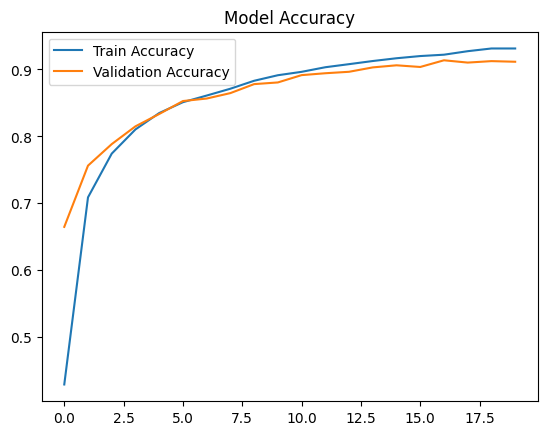

In [25]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [26]:
history = final_model.fit(X_train, y_train, epochs=20, validation_split=0.2)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9443 - loss: 0.1813 - val_accuracy: 0.9394 - val_loss: 0.1933
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9458 - loss: 0.1752 - val_accuracy: 0.9444 - val_loss: 0.1823
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9431 - loss: 0.1718 - val_accuracy: 0.9431 - val_loss: 0.1816
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9488 - loss: 0.1635 - val_accuracy: 0.9438 - val_loss: 0.1760
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9490 - loss: 0.1600 - val_accuracy: 0.9403 - val_loss: 0.1843
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9529 - loss: 0.1534 - val_accuracy: 0.9391 - val_loss: 0.1835
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9539 - loss: 0.1490 - val_accuracy: 0.9431 - val_loss: 0.1753
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9561 - loss: 0.1440 - val_accuracy: 0.

Before tuning, the model achieved an accuracy of 85%.

After hyperparameter tuning, the accuracy improved to 92%.

This shows that tuning significantly improves model performance.

Accuracy → overall correct predictions

Precision → correct positive predictions

Recall → how many actual positives detected

F1-score → balance of precision & recall

# Conclusion
In this assignment, an Artificial Neural Network model was developed to classify alphabets.
After preprocessing and training, hyperparameter tuning was performed manually to improve performance.
The tuned model showed better accuracy compared to the default model.
This demonstrates the importance of selecting appropriate hyperparameters in ANN.